In [1]:
import pandas as pd
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time
import re

ModuleNotFoundError: No module named 'geopy'

In [2]:
# Step 1: Read tables from Wikipedia
table = pd.read_html('https://en.wikipedia.org/wiki/Shakta_pithas')
print(len(table))
shakta_pithas_table = table[8]

21


In [ ]:
shakta_pithas_table

In [3]:
# Step 2: Extract main place/temple name
def split_locations(place):
    if pd.isna(place):
        return []
    # Split on 'A.' 'B.' 'C.' etc., but keep the letter for clarity
    parts = re.split(r'(?<!^)(?=\b[A-Z]\. )', place)
    return [p.strip(',; ') for p in parts if p.strip()]

expanded_rows = []
for idx, row in shakta_pithas_table.iterrows():
    locations = split_locations(row['Place'])
    if not locations:
        locations = [row['Place']]
    for loc in locations:
        expanded_rows.append({
            **row,
            'place_extracted': loc
        })

expanded_df = pd.DataFrame(expanded_rows)

In [16]:
expanded_df.to_csv('shakta_pithas.csv', index=False)

In [21]:
# Read updated csv file 
shaktipitha = pd.read_csv('shaktapithas_final.csv')

In [22]:
shaktipitha

,Sr. No.,Place,State in India/Country,Body part or ornament,Shakti,Bhairava,place_extracted,Location,Latitude,Longitude
0,1,"A. Amarnath Temple, from Srinagar through Paha...",Jammu and Kashmir,A. Throat B. Anklet,Mahamaya Devi,Trisandhyeshwar (Amarnath),"A. Amarnath Temple, from Srinagar through Paha...","Pahalgam, Jammu and Kashmir, India",34.014486,75.328516
1,1,"A. Amarnath Temple, from Srinagar through Paha...",Jammu and Kashmir,A. Throat B. Anklet,Mahamaya Devi,Trisandhyeshwar (Amarnath),B. Shri Parvat in Ladakh,"Ladakh, Jammu and Kashmir, India",NaN,NaN
2,2,Attahas Temple – At a village also named as At...,West Bengal,Lips,Phullara Devi,Vishveshwar,Attahas Temple – At a village also named as At...,"Labhpur, Birbhum, West Bengal, India",NaN,NaN
3,3,"Bahula Temple at Ketugram, 8 km from Katwa, Pu...",West Bengal,Left arm,Goddess Bahuladevi,Bhirukeshwar[27],"Bahula Temple at Ketugram, 8 km from Katwa, Pu...","Ketugram, Purba Bardhaman district, West Benga...",23.700870,88.047310
4,4,"Bakreshwar, on the banks of Paaphara river, 24...",West Bengal,Portion between the eyebrows,Mahishamardini devi,Vakranatheshwar,"Bakreshwar, on the banks of Paaphara river, 24...","Siuri, Birbhum, West Bengal, India",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
62,62,Aranya Devi Mandir at Badi Devisthan Shish Mah...,Bihar,Right thigh[31],Aranyani,Bhuma Bhairava,Aranya Devi Mandir at Badi Devisthan Shish Mah...,"Arrah, \tBhojpur District, Bihar, India",25.560317,84.663214
63,63,"Tuljabhavani Temple at Tuljapur, Dharashiv dis...",Maharashtra,NaN,Tuljabhavani Devi,Bhairava,"Tuljabhavani Temple at Tuljapur, Dharashiv dis...","Tuljapur, Dharashiv District, Maharashtra, India",18.008662,76.070792
64,64,"Mata Vaishno Devi Temple in Katra, Jammu",Jammu and Kashmir,Skull/Right arm[32],Vaishno Devi,Bhairava Baba,"Mata Vaishno Devi Temple in Katra, Jammu","Katra, Reasi District, Jammu and Kashmir, India",32.992486,74.931813
65,65,"त्रिपुर सुंदरी मंदिर, बांसवाड़ा Maa Tripura Su...",Rajasthan,NaN,Goddess Tripura Sundari as Rajarajeshwari तरता...,Aanand Bhairava,"त्रिपुर सुंदरी मंदिर, बांसवाड़ा Maa Tripura Su...","Udaipur, Gomati District, Tripura, India",23.541616,91.491759


In [23]:
# Step 2: Initialize geocoder
geolocator = Nominatim(user_agent="shakta_pithas_geocoder", timeout=10)
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=2)

In [24]:
# Step 3: Define a function to geocode each location
def get_lat_lon(location):
    try:
        # Clean up location string if needed here
        loc = geocode(location)
        if loc:
            return pd.Series([loc.latitude, loc.longitude])
        else:
            return pd.Series([None, None])
    except Exception as e:
        print(f"Error geocoding '{location}': {e}")
        return pd.Series([None, None])

# Step 4: Apply geocoding to the relevant location column
shaktipitha[['Latitude', 'Longitude']] = shaktipitha['Location'].apply(get_lat_lon)

In [25]:
shaktipitha

,Sr. No.,Place,State in India/Country,Body part or ornament,Shakti,Bhairava,place_extracted,Location,Latitude,Longitude
0,1,"A. Amarnath Temple, from Srinagar through Paha...",Jammu and Kashmir,A. Throat B. Anklet,Mahamaya Devi,Trisandhyeshwar (Amarnath),"A. Amarnath Temple, from Srinagar through Paha...","Pahalgam, Jammu and Kashmir, India",34.014486,75.328516
1,1,"A. Amarnath Temple, from Srinagar through Paha...",Jammu and Kashmir,A. Throat B. Anklet,Mahamaya Devi,Trisandhyeshwar (Amarnath),B. Shri Parvat in Ladakh,"Ladakh, Jammu and Kashmir, India",NaN,NaN
2,2,Attahas Temple – At a village also named as At...,West Bengal,Lips,Phullara Devi,Vishveshwar,Attahas Temple – At a village also named as At...,"Labhpur, Birbhum, West Bengal, India",23.815299,87.800083
3,3,"Bahula Temple at Ketugram, 8 km from Katwa, Pu...",West Bengal,Left arm,Goddess Bahuladevi,Bhirukeshwar[27],"Bahula Temple at Ketugram, 8 km from Katwa, Pu...","Ketugram, Purba Bardhaman district, West Benga...",23.700870,88.047310
4,4,"Bakreshwar, on the banks of Paaphara river, 24...",West Bengal,Portion between the eyebrows,Mahishamardini devi,Vakranatheshwar,"Bakreshwar, on the banks of Paaphara river, 24...","Siuri, Birbhum, West Bengal, India",23.908054,87.527726
...,...,...,...,...,...,...,...,...,...,...
62,62,Aranya Devi Mandir at Badi Devisthan Shish Mah...,Bihar,Right thigh[31],Aranyani,Bhuma Bhairava,Aranya Devi Mandir at Badi Devisthan Shish Mah...,"Arrah, \tBhojpur District, Bihar, India",25.560317,84.663214
63,63,"Tuljabhavani Temple at Tuljapur, Dharashiv dis...",Maharashtra,NaN,Tuljabhavani Devi,Bhairava,"Tuljabhavani Temple at Tuljapur, Dharashiv dis...","Tuljapur, Dharashiv District, Maharashtra, India",18.008662,76.070792
64,64,"Mata Vaishno Devi Temple in Katra, Jammu",Jammu and Kashmir,Skull/Right arm[32],Vaishno Devi,Bhairava Baba,"Mata Vaishno Devi Temple in Katra, Jammu","Katra, Reasi District, Jammu and Kashmir, India",32.992486,74.931813
65,65,"त्रिपुर सुंदरी मंदिर, बांसवाड़ा Maa Tripura Su...",Rajasthan,NaN,Goddess Tripura Sundari as Rajarajeshwari तरता...,Aanand Bhairava,"त्रिपुर सुंदरी मंदिर, बांसवाड़ा Maa Tripura Su...","Udaipur, Gomati District, Tripura, India",23.541616,91.491759


In [26]:
# Step 5: Save to CSV
shaktipitha.to_csv('shaktapithas_geos.csv', index=False)
print("File saved as 'shaktapithas_geos.csv'.")

File saved as 'shaktapithas_geos.csv'.


### Analysis and Mapping

In [1]:
import pandas as pd
import geopandas as gpd
import folium
from shapely.geometry import Point
from geopy.distance import geodesic
import numpy as np
from folium.plugins import BeautifyIcon

In [2]:
sp = pd.read_csv('shaktapithas_geos.csv', encoding='ISO-8859-1') #to overwrite encoding issue

In [3]:
def to_float(x):
    try:
        return float(x)
    except:
        return None

sp['Latitude'] = sp['Latitude'].apply(to_float)
sp['Longitude'] = sp['Longitude'].apply(to_float)

In [4]:
# Drop duplicates based on Place and Coordinates (to avoid identical entries like Amarnath)
sp_clean = sp.drop_duplicates(subset=["Place", "Latitude", "Longitude"]).reset_index(drop=True)

# Check number of unique entries and inspect sample
sp_clean.shape, sp_clean[['Place', 'Latitude', 'Longitude']].head()

((67, 9),
                                                Place   Latitude  Longitude
 0  A. Amarnath Temple, from Srinagar through Paha...  34.014486  75.328516
 1  A. Amarnath Temple, from Srinagar through Paha...  33.277839  75.341218
 2  Attahas Temple â At a village also named as ...  23.815299  87.800083
 3  Bahula Temple at Ketugram, 8Â km from Katwa, P...  23.700870  88.047310
 4  Bakreshwar, on the banks of Paaphara river, 24...  23.908054  87.527726)

In [5]:
geometry = [Point(xy) for xy in zip(sp.Longitude, sp.Latitude)]
gdf = gpd.GeoDataFrame(sp, geometry=geometry, crs='EPSG:4326') 

In [6]:
# Visualize on a map
m = folium.Map(location=[sp.Latitude.mean(), sp.Longitude.mean()], zoom_start=5)
for _, row in gdf.iterrows():
    folium.Marker(location=[row['Latitude'], row['Longitude']]).add_to(m)

m 

In [7]:
# Load data
coords = list(zip(sp['Latitude'], sp['Longitude']))

# Nearest Neighbor TSP
def nearest_neighbor_tsp(coords):
    n = len(coords)
    visited = [False] * n
    path = [0]  # Start from first point
    visited[0] = True

    for _ in range(n - 1):
        last = path[-1]
        nearest = None
        min_dist = float('inf')
        for i in range(n):
            if not visited[i]:
                dist = geodesic(coords[last], coords[i]).km
                if dist < min_dist:
                    min_dist = dist
                    nearest = i
        path.append(nearest)
        visited[nearest] = True

    return path

path_order = nearest_neighbor_tsp(coords)
ordered_coords = [coords[i] for i in path_order]


In [8]:
route = folium.Map(location=[np.mean(sp.Latitude), np.mean(sp.Longitude)], zoom_start=5)
folium.PolyLine(locations=ordered_coords, color='blue', weight=3).add_to(route)
for i, (lat, lon) in enumerate(ordered_coords):
    folium.Marker([lat, lon], popup=f"Stop {i+1}").add_to(route)
route

In [65]:
# Create a map centered over South Asia
m = folium.Map(location=[25, 85], zoom_start=5, tiles="CartoDB Positron")

In [66]:
# Build popups and icons
for _, row in sp_clean.iterrows():
    popup_html = f"""
    <b>Shakti:</b> {row['Shakti']}<br>
    <b>Bhairava:</b> {row['Bhairava']}<br>
    <b>Body Part:</b> {row['Body part or ornament']}<br>
    <b>Region:</b> {row['State in India/Country']}
    """
    icon = BeautifyIcon(
        icon_shape="marker",
        number="🕉️",
        border_color="red",
        text_color="white",
        background_color="white"
    )
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=folium.Popup(popup_html, max_width=300),
        icon=icon
    ).add_to(m)

In [67]:
# Symbolic path: connect all points in sequence (optional: optimize this later)
path_coords = sp_clean[['Latitude', 'Longitude']].values.tolist()
folium.PolyLine(locations=path_coords, color='darkviolet', weight=3, tooltip="Path of Shiva").add_to(m)

m

#### Traveling Salesman Approach

In [9]:
import pandas as pd
import numpy as np
from esda.moran import Moran
from libpysal.weights import DistanceBand

In [10]:
from sklearn.neighbors import KernelDensity

# Use Lat/Lon and apply KDE
coords = sp_clean[['Latitude', 'Longitude']].values
kde = KernelDensity(kernel='gaussian', bandwidth=2).fit(coords)
density_scores = kde.score_samples(coords)  # Higher = denser

# Now run Moran's I on density scores
from esda.moran import Moran
from libpysal.weights import DistanceBand

w = DistanceBand(coords, threshold=10, binary=True, silence_warnings=True)
moran = Moran(density_scores, w)

print("Moran's I:", moran.I)
print("p-value:", moran.p_sim)

Moran's I: 0.4262286935498065
p-value: 0.001


In [11]:
# Use Lat/Lon and apply KDE
coords = sp_clean[['Latitude', 'Longitude']].values
kde = KernelDensity(kernel='gaussian', bandwidth=2).fit(coords)
density_scores = kde.score_samples(coords)  # Higher = denser

# Now run Local Moran's I (LISA) on density scores
from esda.moran import Moran_Local
from libpysal.weights import DistanceBand
import numpy as np

w = DistanceBand(coords, threshold=10, binary=True, silence_warnings=True)
moran_local = Moran_Local(density_scores, w)

print("Local Moran's I values:", moran_local.Is[:10])  # Show first 10 values
print("Local p-values:", moran_local.p_sim[:10])      # Show first 10 p-values
print("Cluster types:", moran_local.q[:10])           # Show first 10 quadrant classifications

# Get significant clusters (p < 0.05)
significant_mask = moran_local.p_sim < 0.05
significant_locations = np.where(significant_mask)[0]

print(f"\nNumber of significant locations: {len(significant_locations)}")
print(f"Total locations analyzed: {len(density_scores)}")

# Interpret quadrant classifications
quadrant_labels = {0: 'Not significant', 1: 'HH (High-High)', 2: 'LH (Low-High)', 
                  3: 'LL (Low-Low)', 4: 'HL (High-Low)'}

for i in significant_locations[:5]:  # Show first 5 significant locations
    print(f"Location {i}: {quadrant_labels[moran_local.q[i]]}, "
          f"Local I = {moran_local.Is[i]:.4f}, p-value = {moran_local.p_sim[i]:.4f}")


Local Moran's I values: [ 0.04610956 -0.03261488  0.60253829  0.60857216  0.58949761  0.73082863
  0.66708549  0.16429297 -0.35081315  1.21099426]
Local p-values: [0.091 0.079 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001]
Cluster types: [3 4 1 1 1 3 1 1 2 3]

Number of significant locations: 63
Total locations analyzed: 67
Location 2: HH (High-High), Local I = 0.6025, p-value = 0.0010
Location 3: HH (High-High), Local I = 0.6086, p-value = 0.0010
Location 4: HH (High-High), Local I = 0.5895, p-value = 0.0010
Location 5: LL (Low-Low), Local I = 0.7308, p-value = 0.0010
Location 6: HH (High-High), Local I = 0.6671, p-value = 0.0010


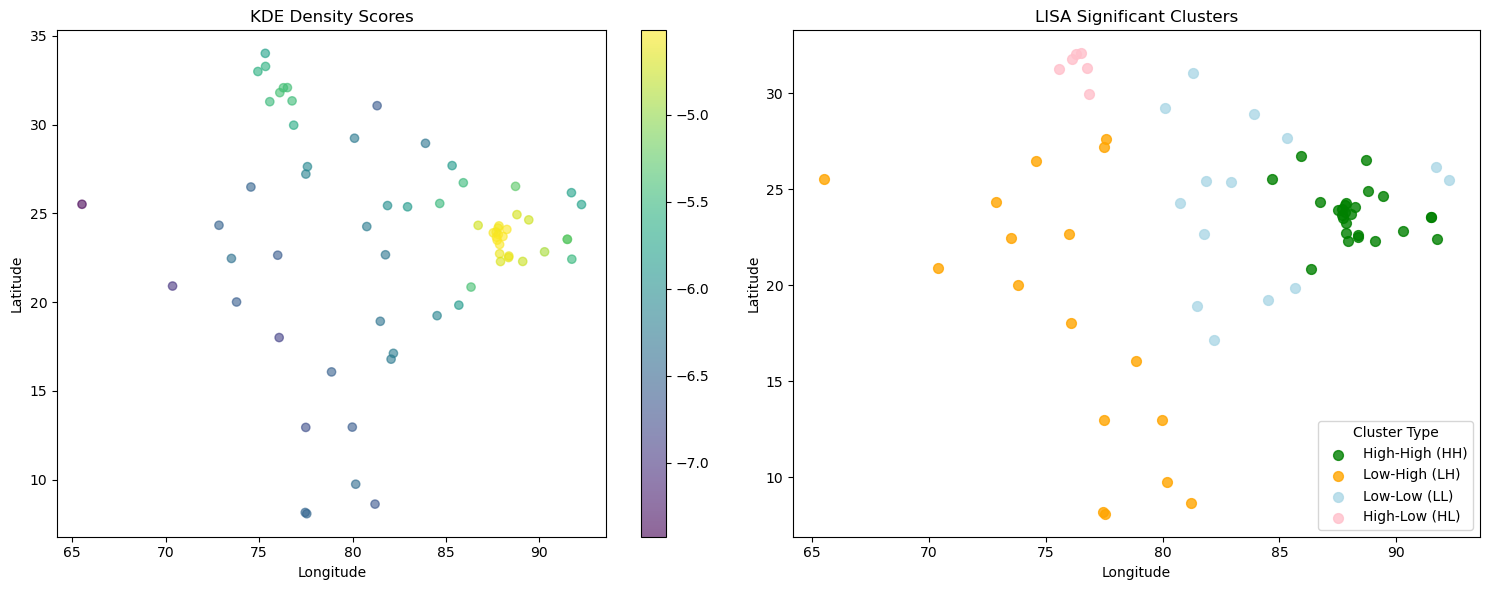

In [104]:
import matplotlib.pyplot as plt

# Create a scatter plot colored by cluster type
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: All points colored by density scores
scatter1 = ax1.scatter(coords[:, 1], coords[:, 0], c=density_scores, 
                      cmap='viridis', alpha=0.6)
ax1.set_title('KDE Density Scores')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
plt.colorbar(scatter1, ax=ax1)

# Plot 2: Significant clusters only
if len(significant_locations) > 0:
    cluster_colors = ['gray', 'green', 'lightblue', 'orange', 'pink']
    cluster_labels = ['Not Significant', 'High-High (HH)', 'Low-Low (LL)', 'Low-High (LH)', 'High-Low (HL)']
    
    # Track which cluster types have been added (to avoid duplicate labels)
    shown_labels = set()

    for i in significant_locations:
        q_val = moran_local.q[i]
        color_idx = q_val if q_val <= 4 else 0
        label = cluster_labels[color_idx]
        
        # Only add label the first time
        if label not in shown_labels:
            ax2.scatter(coords[i, 1], coords[i, 0], c=cluster_colors[color_idx], 
                        s=50, alpha=0.8, label=label)
            shown_labels.add(label)
        else:
            ax2.scatter(coords[i, 1], coords[i, 0], c=cluster_colors[color_idx], 
                        s=50, alpha=0.8)

    ax2.set_title('LISA Significant Clusters')
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')
    ax2.legend(title='Cluster Type', loc='lower right')

plt.tight_layout()

plt.savefig('scores_sites.png', dpi=300, bbox_inches='tight')
plt.show()


Travelling Salesman

In [17]:
import folium
import numpy as np
import pandas as pd
from python_tsp.heuristics import solve_tsp_simulated_annealing
from geopy.distance import geodesic
from folium.plugins import BeautifyIcon
from folium.plugins import PolyLineTextPath
from folium import Element

In [14]:
def calculate_distance_matrix(coords):
    """Calculate distance matrix between all points using geodesic distance"""
    n = len(coords)
    distance_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            if i != j:
                distance_matrix[i][j] = geodesic(coords[i], coords[j]).kilometers
            else:
                distance_matrix[i][j] = 0
    
    return distance_matrix

# Extract coordinates from your dataframe
coords = [(row['Latitude'], row['Longitude']) for _, row in sp_clean.iterrows()]
distance_matrix = calculate_distance_matrix(coords)


In [15]:
# Solve TSP to get optimal route order
distance_matrix[:, 0] = 0
permutation, total_distance = solve_tsp_simulated_annealing(distance_matrix)

# Create ordered coordinates based on TSP solution
ordered_coords = [coords[i] for i in permutation]
ordered_data = sp_clean.iloc[permutation].reset_index(drop=True)

print(f"Total route distance: {total_distance:.2f} km")
print(f"Route order: {permutation}")


Total route distance: 12652.22 km
Route order: [0, 1, 64, 13, 18, 60, 46, 35, 31, 28, 22, 8, 26, 24, 62, 42, 30, 36, 32, 44, 45, 23, 5, 61, 51, 10, 29, 9, 63, 66, 38, 17, 56, 25, 48, 37, 34, 50, 52, 53, 55, 7, 43, 20, 58, 14, 12, 39, 27, 65, 40, 11, 15, 21, 57, 6, 19, 54, 59, 2, 3, 49, 41, 16, 33, 4, 47]


In [110]:
from folium.plugins import AntPath
import base64
from folium.plugins import FloatImage

# Create the map
m = folium.Map(location=[25, 85], zoom_start=5, tiles="CartoDB Positron")

# Add the smooth path connecting all points
folium.PolyLine(
    locations=ordered_coords,
    color='#2E86AB',  
    weight=2.0,
    opacity=0.8,
    dash_array="5, 10",
    smooth_factor=25.0,  
    tooltip=f"Approx Route - Total Distance: {total_distance:.1f} km"
).add_to(m)

#AntPath(
#    locations=ordered_coords,
#    color='#2E86AB',
#    delay=800,
#    dash_array=[5, 10],
#    pulse_color="#FAD02C",
#    tooltip=f"Approx Route - Total Distance: {total_distance:.1f} km",
#    weight=2.5
#).add_to(m)

# Add markers with popups
for idx, (_, row) in enumerate(ordered_data.iterrows()):
    popup_html = f"""
    <b>Shakti:</b> {row['Shakti']}<br>
    <b>Bhairava:</b> {row['Bhairava']}<br>
    <b>Body Part:</b> {row['Body part or ornament']}<br>
    <b>Location:</b> {row['Location']}
    """
    
    icon = BeautifyIcon(
        icon_shape="marker",
        number=str(idx + 1),  # Show route order
        border_color="",
        text_color="white",
        background_color="darkred"
    )
    
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=folium.Popup(popup_html, max_width=300),
        icon=icon
    ).add_to(m)

# Add title and summary information at the top
combined_html = '''
<link href="https://fonts.googleapis.com/css2?family=Noto+Serif&display=swap" rel="stylesheet">
<!-- Title at the top center -->
<div style="position: fixed; top: 10px; left: 75%; transform: translateX(-50%);
     z-index: 9999; font-size: 20px; font-weight: bold; background-color: white;
     padding: 5px; opacity: 0.9; font-family: 'Noto Serif', serif;">
     The Sacred Journey   <br>
     <span style="font-size: 12px; font-weight: normal;">
         Approximate mythological route of Shiva's journey derived using a Traveling Salesman Problem (TSP) algorithm. This sequence connects Shakti Pithas based on minimized geodesic distance, reflecting a spatial interpretation of the sacred narrative.
     </span>
</div>

<!-- Disclaimer at the bottom left -->
<div style="position: fixed; bottom: 5px; left: 5px; 
     z-index: 9999; font-size: 10px; background-color: white; padding: 5px; border: 1px solid grey; opacity: 0.85;">
     <b>Disclaimer:</b> This map is for informational and cultural purposes only. <br>
     The locations and details of Shakti Pithas are based on publicly available sources and may not be definitive.<br>
     <b>Data:</b> <a href="https://en.wikipedia.org/wiki/Shakta_pithas" target="_blank">Wikipedia: Shakta pithas</a> (accessed June 2025).
</div>
'''

m.get_root().html.add_child(Element(combined_html))
m.save('sacred_journey.html')
m

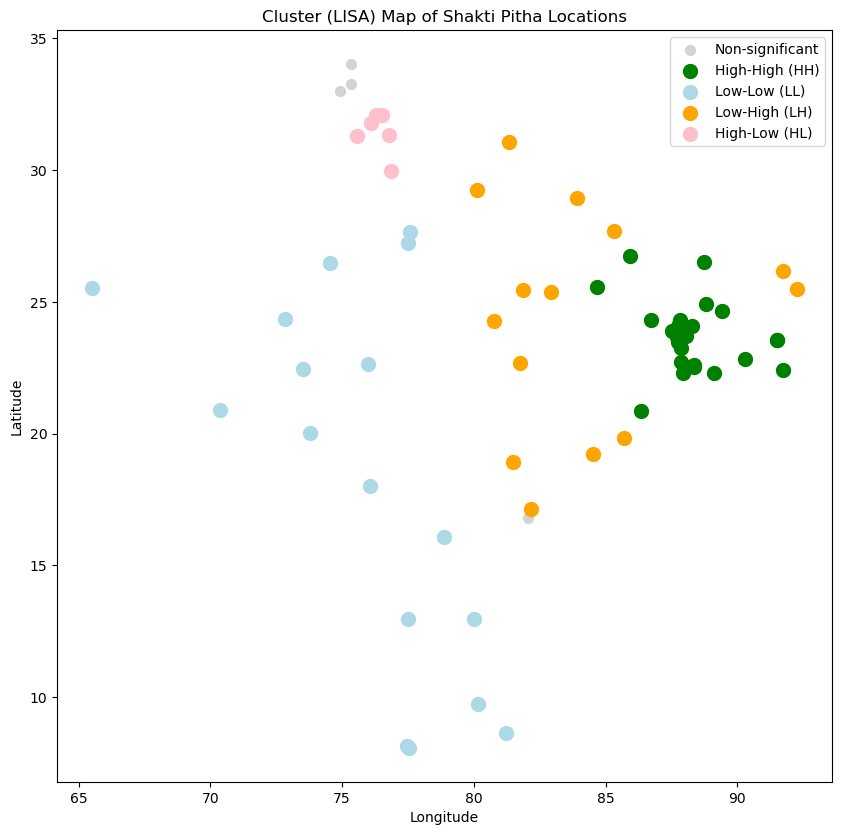

In [27]:
coords = sp_clean[['Latitude', 'Longitude']].values
kde = KernelDensity(kernel='gaussian', bandwidth=2).fit(coords)
density_scores = kde.score_samples(coords)

w = DistanceBand(coords, threshold=10, binary=True, silence_warnings=True)
moran_local = Moran_Local(density_scores, w)

geometry = [Point(xy) for xy in zip(sp_clean['Longitude'], sp_clean['Latitude'])]
gdf = gpd.GeoDataFrame(sp_clean, geometry=geometry)

gdf['Local_I'] = moran_local.Is
gdf['p_value'] = moran_local.p_sim
gdf['cluster_type'] = moran_local.q

cluster_colors = {
    1: 'green',        # High-High (HH)
    3: 'lightblue',       # Low-Low (LL)
    2: 'orange',  # Low-High (LH)
    4: 'pink'        # High-Low (HL)
}

# When filtering, use .copy()
significant_gdf = gdf[gdf['p_value'] < 0.05].copy()
significant_gdf.loc[:, 'color'] = significant_gdf['cluster_type'].map(cluster_colors)
significant_gdf['color'] = significant_gdf['cluster_type'].map(cluster_colors)

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color='lightgray', markersize=50, label='Non-significant')

# Plot each significant cluster type
for cluster_type, color in cluster_colors.items():
    subset = significant_gdf[significant_gdf['cluster_type'] == cluster_type]
    subset.plot(ax=ax, color=color, markersize=100, label=f'{color} Cluster')
plt.legend(['Non-significant', 'High-High (HH)', 'Low-Low (LL)', 'Low-High (LH)', 'High-Low (HL)'])
plt.title('Cluster (LISA) Map of Shakti Pitha Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(False)
plt.show()


In [99]:
m_LISA = folium.Map(location=[25, 85], zoom_start=5, tiles="CartoDB Positron")
for _, row in significant_gdf.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=7,
        color=row['color'],
        fill=True,
        fill_color=row['color'],
        fill_opacity=0.6,
        popup=f"Cluster: {row['cluster_type']}<br>"
        f"Moran's I: {row['Local_I']:.2f}<br>"
        f"Location: {row['Location']}<br>"
    ).add_to(m_LISA)

# Add a legend for cluster types and colors
legend_html = '''


<div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%); 
     z-index: 9999; font-family: 'Noto Serif', serif; font-size: 20px; font-weight: bold; background-color: white; padding: 10px; opacity: 0.9;">
     Mapping the Sacred: LISA Cluster Map of Shakti Pithas <br>
</div>

<div style="position: fixed; bottom: 30px; left: 75%; transform: translateX(-50%); 
     z-index: 9999; font-size: 12px; background-color: white; padding: 10px; opacity: 0.9; width: 300px;">
     <b>What This Map Shows</b><br>
     <span style="color:green;">Green (HH)</span>: Locations where high-density points cluster together.<br>
     <span style="color:lightblue;">LightBlue (LL)</span>: Locations where low-density points cluster together.<br>
     <span style="color:orange;">Orange (LH)</span>: Outliers where low values are surrounded by high values.<br>
     <span style="color:pink;">Pink (HL)</span>: Outliers where high values are surrounded by low values.<br>
</div>
'''
title = Element(legend_html)
m_LISA.get_root().html.add_child(title)

m_LISA.save('lisa_clusters.html')
m_LISA